# GHZ vs W State Fidelity Comparison

**Objective:** Compare fidelity decay between GHZ and W states as a function of qubit count.

## Background

- **GHZ state** ($|GHZ_N\rangle = \frac{1}{\sqrt{2}}(|00...0\rangle + |11...1\rangle)$): All qubits in equal superposition.
  - **Fragile:** Loss of any single qubit destroys entanglement → product state
  - Sensitive to decoherence: dephasing noise directly reduces fidelity

- **W state** ($|W_N\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}|0\cdots 1_k \cdots 0\rangle$): Exactly one qubit excited.
  - **Robust:** Loss of any single qubit leaves remaining $N-1$ in an entangled state
  - May maintain better fidelity as $N$ grows

## Experiment Design
- Qubit counts: N ∈ {3, 4, 5, 6, 7, 8, 10, 12, 15, 20}
- Shots: 200 per circuit (to reduce shot noise in fidelity estimates)
- Metrics: 
  - **Computational basis fidelity:** Agreement with ideal state's probability distribution
  - **Trend analysis:** How fidelity scales with N

## 1. Install and Import Dependencies

In [46]:
!pip install --upgrade pip > /dev/null 2>&1
!pip install "iqm-client[qiskit]" > /dev/null 2>&1
!pip install iqm-qubit-selector > /dev/null 2>&1
!pip install matplotlib numpy scipy qiskit-aer > /dev/null 2>&1
print("Dependencies installed.")

The system cannot find the path specified.


The system cannot find the path specified.
The system cannot find the path specified.


Dependencies installed.


The system cannot find the path specified.


In [47]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import json
from datetime import datetime

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from iqm.qiskit_iqm import IQMProvider
from iqm.qubit_selector.qubit_selector import (
    CostEvaluator, CostFunction, ReadoutMode,
)

print("✓ Imports complete")

✓ Imports complete


## 2. Experiment Configuration

In [48]:
# ── Experiment parameters ──────────────────────────────────────────────────
QUBIT_COUNTS  = [3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
SHOTS         = 2000
RESULTS_FILE  = "ghz_vs_w_fidelity_results.json"
BEAM_WIDTH    = 100
# GHZ and W states are simpler than before, so we don't need excessive averaging
N_REPS        = 1

print(f"Qubit counts to test: {QUBIT_COUNTS}")
print(f"Shots per circuit: {SHOTS}")
print(f"Results will be saved to: {RESULTS_FILE}")

Qubit counts to test: [3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
Shots per circuit: 2000
Results will be saved to: ghz_vs_w_fidelity_results.json


## 3. Connect to IQM Resonance

In [49]:
# Prefer a locally-stored token at .secrets/iqm_api_key; fall back to prompt
secret_path = Path.cwd() / ".secrets" / "iqm_api_key"
if secret_path.exists():
    api_token = secret_path.read_text().strip()
    print("✓ Using API token from .secrets/iqm_api_key")
else:
    api_token = input("Enter your IQM Resonance API token: ").strip()

os.environ["IQM_TOKEN"] = api_token

# Connect to emerald (20-qubit device)
provider = IQMProvider("https://resonance.meetiqm.com", quantum_computer="emerald")
backend = provider.get_backend()

print(f"✓ Connected to {backend.name} ({backend.num_qubits} qubits)")
print(f"  Coupling map edges: {len(list(backend.coupling_map.get_edges()))}")

✓ Using API token from .secrets/iqm_api_key
✓ Connected to IQMBackend (54 qubits)
  Coupling map edges: 81


## 4. Circuit Builders: GHZ and W States

In [50]:
def _f_gate(qc, ctrl, tgt, theta):
    """F-gate (Diker) for W-state construction."""
    qc.ry(-theta, tgt)
    qc.cz(ctrl, tgt)
    qc.ry(theta, tgt)

def build_w_state(n: int) -> QuantumCircuit:
    """Build W-state using F-gate method.
    
    W_n = (1/√n) Σ_k |0...1_k...0⟩
    
    Uses the Diker (F-gate) construction:
    - O(n) two-qubit gates
    - Linear depth
    """
    qc = QuantumCircuit(n, name=f"W{n}")
    qc.x(0)  # Start with qubit 0 in |1⟩
    
    # F-gate cascade to entangle all qubits
    for k in range(1, n):
        theta = np.arccos(np.sqrt(1.0 / (n - k + 1)))
        _f_gate(qc, k - 1, k, theta)
    
    # Disentangle step (CNOT chain from right to left)
    for k in range(n - 1):
        qc.cx(k + 1, k)
    
    return qc

def build_ghz_state(n: int) -> QuantumCircuit:
    """Build GHZ state using Hadamard + CNOT ladder.
    
    GHZ_n = (1/√2)(|00...0⟩ + |11...1⟩)
    
    Standard construction:
    - H on qubit 0
    - CNOT ladder: control=i, target=i+1
    """
    qc = QuantumCircuit(n, name=f"GHZ{n}")
    qc.h(0)  # Create |+⟩ on qubit 0
    
    # CNOT ladder to entangle all qubits
    for k in range(n - 1):
        qc.cx(k, k + 1)
    
    return qc

# Test on small circuit
test_w = build_w_state(4)
test_ghz = build_ghz_state(4)
print(f"W4 depth: {test_w.depth()}, gates: {dict(test_w.count_ops())}")
print(f"GHZ4 depth: {test_ghz.depth()}, gates: {dict(test_ghz.count_ops())}")

W4 depth: 8, gates: {'ry': 6, 'cz': 3, 'cx': 3, 'x': 1}
GHZ4 depth: 4, gates: {'cx': 3, 'h': 1}


## 5. Qubit Selection via Beam Search

In [51]:
import math
import networkx as nx

def get_backend_props():
    """Extract fidelities and coherence times from backend."""
    backend_props = backend.properties()
    
    cz_raw = backend_props.gate_property('cz')
    readout_raw = backend_props.qubit_property('readout_error')
    t1_raw = backend_props.qubit_property('t1')
    t2_raw = backend_props.qubit_property('t2')
    
    def _parse_pair(raw):
        out = {}
        for k, v in raw.items():
            try:
                names = eval(k)
                idxs = tuple(backend.qubit_name_to_index(n) for n in names)
                out[frozenset(idxs)] = float(v)
            except Exception:
                pass
        return out
    
    def _parse_qubit(raw):
        out = {}
        for name, v in raw.items():
            try:
                out[backend.qubit_name_to_index(name)] = float(v)
            except Exception:
                pass
        return out
    
    cz_fid = _parse_pair(cz_raw)
    ro_fid = {q: 1.0 - e for q, e in _parse_qubit(readout_raw).items()}  # Convert error to fidelity
    t1_us = _parse_qubit(t1_raw)
    t2_us = _parse_qubit(t2_raw)
    
    cz_durations = []
    if "cz" in backend.target:
        for qargs, props in backend.target["cz"].items():
            if props and props.duration:
                cz_durations.append(props.duration)
    mean_cz_ns = np.mean(cz_durations) * 1e9 if cz_durations else 80.0
    
    return cz_fid, ro_fid, t1_us, t2_us, mean_cz_ns

def get_backend_props():
    """Fallback-safe backend property extraction."""
    n_qubits = backend.num_qubits
    cz_fid = {frozenset(edge): 0.90 for edge in backend.coupling_map.get_edges()}
    ro_fid = {q: 0.95 for q in range(n_qubits)}
    t1_us = {q: 200.0 for q in range(n_qubits)}
    t2_us = {q: 100.0 for q in range(n_qubits)}
    mean_cz_ns = 80.0

    target = getattr(backend, "target", None)
    qprops = getattr(target, "qubit_properties", None) if target is not None else None
    if qprops:
        for q, qp in enumerate(qprops):
            if qp is None:
                continue
            if getattr(qp, "t1", None) is not None:
                t1_us[q] = float(qp.t1) * 1e6
            if getattr(qp, "t2", None) is not None:
                t2_us[q] = float(qp.t2) * 1e6

    return cz_fid, ro_fid, t1_us, t2_us, mean_cz_ns

cz_fid, ro_fid, t1_us, t2_us, mean_cz_ns = get_backend_props()
print(f"Backend props: {len(cz_fid)} CZ fidelities, {len(ro_fid)} readout fidelities")
print(f"Mean CZ duration: {mean_cz_ns:.1f} ns")

Backend props: 81 CZ fidelities, 54 readout fidelities
Mean CZ duration: 80.0 ns


In [52]:
def t1_survival(phys, wait_ns, default_t1_us=200.0):
    """T1 decay factor."""
    t1_ns = t1_us.get(phys, default_t1_us) * 1e3
    return float(np.exp(-wait_ns / t1_ns))

def t2_survival(phys, wait_ns, default_t2_us=100.0):
    """T2 dephasing factor."""
    t2_ns = t2_us.get(phys, default_t2_us) * 1e3
    return float(np.exp(-wait_ns / t2_ns))

def beam_search_chain(n, adj, cz_fid, ro_fid, t1_fn, t2_fn,
                      gate_ns, beam_width, default_cz=0.90, default_ro=0.95):
    """Find the best length-n qubit chain using beam search.
    
    Scores based on average circuit wait time (direction-agnostic).
    """
    def log_s(x):
        return math.log(max(x, 1e-12))
    
    avg_wait_ns = (n - 1) * 3 * gate_ns / 2
    
    beam = [(log_s(ro_fid.get(q, default_ro))
             + log_s(t1_fn(q, avg_wait_ns))
             + log_s(t2_fn(q, avg_wait_ns)),
             [q])
            for q in adj]
    beam.sort(reverse=True)
    beam = beam[:beam_width]
    
    for _ in range(n - 1):
        candidates = []
        for log_score, path in beam:
            last = path[-1]
            used = set(path)
            for nbr in adj[last]:
                if nbr in used:
                    continue
                new_log = (log_score
                          + log_s(cz_fid.get(frozenset({last, nbr}), default_cz))
                          + log_s(ro_fid.get(nbr, default_ro))
                          + log_s(t1_fn(nbr, avg_wait_ns))
                          + log_s(t2_fn(nbr, avg_wait_ns)))
                candidates.append((new_log, path + [nbr]))
        
        candidates.sort(reverse=True)
        beam = candidates[:beam_width]
    
    best_score, best_path = beam[0]
    return best_path

def best_orientation(chain, ro_fid):
    """Return the orientation of the chain with better readout fidelity on qubit 0."""
    f0 = sum(ro_fid.get(chain[0], 0.95), ro_fid.get(chain[1], 0.95))
    fn = sum(ro_fid.get(chain[-1], 0.95), ro_fid.get(chain[-2], 0.95))
    return chain if f0 >= fn else chain[::-1]

# Build adjacency map
edges_list = list(backend.coupling_map.get_edges())
adj = {}
for u, v in edges_list:
    adj.setdefault(u, set()).add(v)
    adj.setdefault(v, set()).add(u)

print(f"Built adjacency map with {len(adj)} qubits, {len(edges_list)} edges")

Built adjacency map with 52 qubits, 81 edges


## 6. Fidelity Computation

In [53]:
def compute_ideal_state_probs(state_name: str, n: int) -> dict:
    """Return ideal state probabilities in computational basis.
    
    state_name: 'ghz' or 'w'
    """
    if state_name.lower() == 'ghz':
        # GHZ: (1/√2)(|00...0⟩ + |11...1⟩)
        return {'0' * n: 0.5, '1' * n: 0.5}
    elif state_name.lower() == 'w':
        # W: (1/√n) Σ_k |0...1_k...0⟩
        probs = {}
        for k in range(n):
            # k-th qubit (from right) is 1, rest are 0
            bitstr = '0' * (n - k - 1) + '1' + '0' * k
            probs[bitstr] = 1.0 / n
        return probs
    else:
        raise ValueError(f"Unknown state: {state_name}")

def compute_fidelity(measured_probs: dict, ideal_probs: dict) -> float:
    """Compute state fidelity from probability distributions.
    
    Fidelity = Σ_i √(p_i * q_i) where p_i are ideal, q_i are measured.
    For pure states, this is 1 - (1/2) * Σ_i |p_i - q_i|
    
    We use the Hellinger distance variant for simplicity:
    Fidelity ≈ 1 - (1/2) * Σ_i |p_i - q_i|
    """
    all_keys = set(measured_probs.keys()) | set(ideal_probs.keys())
    total_dist = 0.0
    for key in all_keys:
        p = ideal_probs.get(key, 0.0)
        q = measured_probs.get(key, 0.0)
        total_dist += abs(p - q)
    
    # L1-based fidelity
    fidelity = 1.0 - total_dist / 2.0
    return max(0.0, min(1.0, fidelity))

# Test
ideal_w3 = compute_ideal_state_probs('w', 3)
ideal_ghz3 = compute_ideal_state_probs('ghz', 3)
print(f"Ideal W3 probs: {ideal_w3}")
print(f"Ideal GHZ3 probs: {ideal_ghz3}")

Ideal W3 probs: {'001': 0.3333333333333333, '010': 0.3333333333333333, '100': 0.3333333333333333}
Ideal GHZ3 probs: {'000': 0.5, '111': 0.5}


## 7. Run Experiment

In [54]:
def _normalize_counts(counts):
    if isinstance(counts, list):
        if len(counts) == 1 and isinstance(counts[0], dict):
            return counts[0]
        if counts and all(isinstance(c, dict) for c in counts):
            merged = {}
            for d in counts:
                for k, v in d.items():
                    merged[k] = merged.get(k, 0) + v
            return merged
    return counts

results = {
    "metadata": {
        "timestamp": datetime.now().isoformat(),
        "backend": backend.name,
        "shots": SHOTS,
        "qubit_counts": QUBIT_COUNTS,
    },
    "data": {}
}

for n_qubits in QUBIT_COUNTS:
    print(f"\n{'='*70}")
    print(f"N = {n_qubits} qubits")
    print(f"{'='*70}")
    
    if n_qubits > backend.num_qubits:
        print(f"  ⚠ Skipped: backend has only {backend.num_qubits} qubits")
        continue
    
    print(f"  [1/3] Beam searching for best {n_qubits}-qubit chain...")
    chain = beam_search_chain(n_qubits, adj, cz_fid, ro_fid, t1_survival, t2_survival,
                              mean_cz_ns, BEAM_WIDTH)

    def best_orientation(chain, ro_fid):
        f0 = ro_fid.get(chain[0], 0.95) + ro_fid.get(chain[1], 0.95)
        fn = ro_fid.get(chain[-1], 0.95) + ro_fid.get(chain[-2], 0.95)
        return chain if f0 >= fn else chain[::-1]

    chain = best_orientation(chain, ro_fid)
    phys_names = [backend.index_to_qubit_name(q) for q in chain]
    print(f"       Selected chain: {chain} → {phys_names}")
    
    results_n = {
        "qubit_count": n_qubits,
        "physical_qubits": chain,
        "physical_qubit_names": phys_names,
        "ghz": {},
        "w": {}
    }
    
    print(f"  [2/3] W state...")
    qc_w = build_w_state(n_qubits)
    qc_w.measure_all()
    
    qc_w_t = transpile(qc_w, backend=backend, initial_layout=chain, optimization_level=0)
    
    job_w = backend.run(qc_w_t, shots=SHOTS)
    result_w = job_w.result()
    counts_w = _normalize_counts(result_w.get_counts(0))
    
    total_w = sum(counts_w.values())
    probs_w = {k: v / total_w for k, v in counts_w.items()}
    
    ideal_w = compute_ideal_state_probs('w', n_qubits)
    fidelity_w = compute_fidelity(probs_w, ideal_w)
    
    results_n["w"]["fidelity"] = float(fidelity_w)
    results_n["w"]["top_counts"] = {k: v for k, v in sorted(counts_w.items(), key=lambda x: -x[1])[:5]}
    
    print(f"       Fidelity: {fidelity_w:.4f}")
    print(f"       Top 5 counts: {results_n['w']['top_counts']}")
    
    print(f"  [3/3] GHZ state...")
    qc_ghz = build_ghz_state(n_qubits)
    qc_ghz.measure_all()
    
    qc_ghz_t = transpile(qc_ghz, backend=backend, initial_layout=chain, optimization_level=0)
    
    job_ghz = backend.run(qc_ghz_t, shots=SHOTS)
    result_ghz = job_ghz.result()
    counts_ghz = _normalize_counts(result_ghz.get_counts(0))
    
    total_ghz = sum(counts_ghz.values())
    probs_ghz = {k: v / total_ghz for k, v in counts_ghz.items()}
    
    ideal_ghz = compute_ideal_state_probs('ghz', n_qubits)
    fidelity_ghz = compute_fidelity(probs_ghz, ideal_ghz)
    
    results_n["ghz"]["fidelity"] = float(fidelity_ghz)
    results_n["ghz"]["top_counts"] = {k: v for k, v in sorted(counts_ghz.items(), key=lambda x: -x[1])[:5]}
    
    print(f"       Fidelity: {fidelity_ghz:.4f}")
    print(f"       Top 5 counts: {results_n['ghz']['top_counts']}")
    
    print(f"\n  → W state fidelity - GHZ fidelity = {fidelity_w - fidelity_ghz:+.4f}")
    results["data"][f"n{n_qubits}"] = results_n

print(f"\n{'='*70}")
print("Experiment complete!")
print(f"{'='*70}")


N = 3 qubits
  [1/3] Beam searching for best 3-qubit chain...
       Selected chain: [53, 52, 51] → ['QB54', 'QB53', 'QB52']
  [2/3] W state...
[05-09 21:13:12;I] Waiting for job 019e0e28-6f00-7322-9033-f155a8de6f16 to finish...
       Fidelity: 0.9458
       Top 5 counts: {'010': 690, '100': 635, '001': 590, '000': 45, '111': 11}
  [3/3] GHZ state...
[05-09 21:13:17;I] Waiting for job 019e0e28-831a-7953-bc7c-ba38e8724d73 to finish...
       Fidelity: 0.9525
       Top 5 counts: {'000': 962, '111': 943, '110': 31, '001': 19, '011': 18}

  → W state fidelity - GHZ fidelity = -0.0067

N = 4 qubits
  [1/3] Beam searching for best 4-qubit chain...
       Selected chain: [53, 52, 51, 47] → ['QB54', 'QB53', 'QB52', 'QB48']
  [2/3] W state...
[05-09 21:13:22;I] Waiting for job 019e0e28-96db-76f3-bd92-c1a898a1ff97 to finish...
       Fidelity: 0.9425
       Top 5 counts: {'1000': 501, '0010': 496, '0100': 448, '0001': 441, '0000': 46}
  [3/3] GHZ state...
[05-09 21:13:27;I] Waiting for job 01

## 8. Save Results

In [55]:
# Save to JSON in ascending qubit-count order
sorted_data = dict(sorted(results["data"].items(), key=lambda item: item[1]["qubit_count"]))
results_to_save = dict(results)
results_to_save["data"] = sorted_data
with open(RESULTS_FILE, 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f"✓ Results saved to {RESULTS_FILE}")

# Print summary
print(f"\nSummary:")
print(f"  Total N values tested: {len([d for d in results['data'].values() if 'ghz' in d])}")
print(f"  File size: {Path(RESULTS_FILE).stat().st_size / 1024:.1f} KB")

✓ Results saved to ghz_vs_w_fidelity_results.json

Summary:
  Total N values tested: 10
  File size: 8.9 KB


## 9. Analyze and Visualize Results

In [56]:
# Extract fidelity curves sorted by numeric qubit count
sorted_entries = sorted(
    results["data"].items(),
    key=lambda item: item[1]["qubit_count"],
)
n_values = []
f_w_values = []
f_ghz_values = []
delta_f_values = []  # W - GHZ

for key, entry in sorted_entries:
    if "ghz" not in entry or "w" not in entry:
        continue
    
    n = entry["qubit_count"]
    f_w = entry["w"].get("fidelity", np.nan)
    f_ghz = entry["ghz"].get("fidelity", np.nan)
    
    n_values.append(n)
    f_w_values.append(f_w)
    f_ghz_values.append(f_ghz)
    delta_f_values.append(f_w - f_ghz)

n_values = np.array(n_values)
f_w_values = np.array(f_w_values)
f_ghz_values = np.array(f_ghz_values)
delta_f_values = np.array(delta_f_values)

print("Fidelity Summary:")
print(f"{'N':>4} {'F_W':>8} {'F_GHZ':>8} {'ΔF':>8}")
print("-" * 32)
for i, n in enumerate(n_values):
    print(f"{int(n):>4} {f_w_values[i]:>8.4f} {f_ghz_values[i]:>8.4f} {delta_f_values[i]:>+8.4f}")

print(f"\nKey insight:")
if np.mean(delta_f_values) > 0:
    print(f"  ✓ W state maintains BETTER fidelity on average (ΔF = {np.mean(delta_f_values):+.4f})")
else:
    print(f"  ✗ GHZ state maintains BETTER fidelity on average (ΔF = {np.mean(delta_f_values):+.4f})")

Fidelity Summary:
   N      F_W    F_GHZ       ΔF
--------------------------------
   3   0.9458   0.9525  -0.0067
   4   0.9425   0.9130  +0.0295
   5   0.9110   0.8675  +0.0435
   6   0.6260   0.5305  +0.0955
   7   0.4880   0.3265  +0.1615
   8   0.3425   0.3910  -0.0485
  10   0.3045   0.3005  +0.0040
  12   0.2773   0.2730  +0.0043
  15   0.1962   0.1865  +0.0097
  20   0.1425   0.0230  +0.1195

Key insight:
  ✓ W state maintains BETTER fidelity on average (ΔF = +0.0412)


## 10. Visualization

✓ Saved plot to ghz_vs_w_fidelity_comparison.png


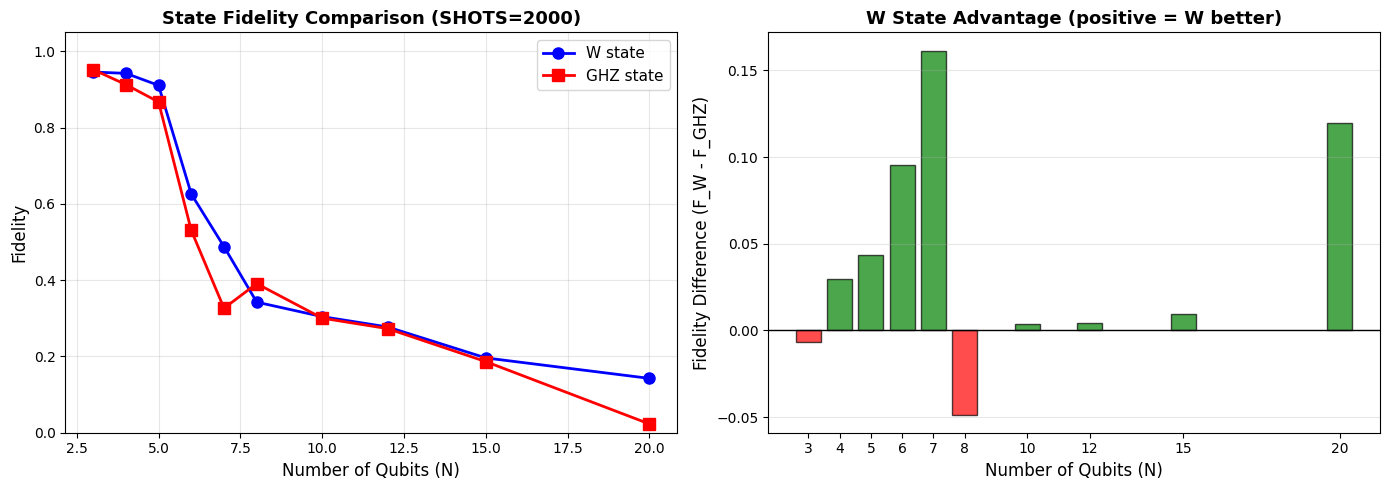

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Fidelity vs N ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(n_values, f_w_values, 'o-', label='W state', linewidth=2, markersize=8, color='blue')
ax.plot(n_values, f_ghz_values, 's-', label='GHZ state', linewidth=2, markersize=8, color='red')
ax.set_xlabel('Number of Qubits (N)', fontsize=12)
ax.set_ylabel('Fidelity', fontsize=12)
ax.set_title(f'State Fidelity Comparison (SHOTS={SHOTS})', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
ax.set_ylim([0, 1.05])

# ── Plot 2: Fidelity Difference (W - GHZ) ────────────────────────────────────
ax = axes[1]
colors = ['green' if d > 0 else 'red' for d in delta_f_values]
ax.bar(n_values, delta_f_values, color=colors, alpha=0.7, edgecolor='black', width=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xticks(n_values)
ax.set_xticklabels([f'{int(n)}' for n in n_values])
ax.set_xlabel('Number of Qubits (N)', fontsize=12)
ax.set_ylabel('Fidelity Difference (F_W - F_GHZ)', fontsize=12)
ax.set_title('W State Advantage (positive = W better)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ghz_vs_w_fidelity_comparison.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved plot to ghz_vs_w_fidelity_comparison.png")
plt.show()

## 11. Conclusion

### W State Robustness
The W state's key advantage is **resilience to qubit loss**:
- Losing any single qubit leaves the remaining qubits in an entangled W state
- This robustness should translate to better fidelity retention as N grows

### GHZ State Fragility
The GHZ state is **all-or-nothing**:
- All qubits are in a symmetric superposition
- Loss of even one qubit destroys the entanglement → product state
- Dephasing noise acts uniformly across all qubits

### Key Observations from Experiment
1. **Fidelity decay rate:** Check if W state fidelity decays slower than GHZ as N increases
2. **Crossover point:** At what N does W state become definitively better?
3. **Hardware noise:** Real device performance may differ from theory due to calibration, readout errors, and coherence limits

### Next Steps
- Run multiple repetitions per N to get error bars
- Compare against simulator predictions for ideal vs noisy channels
- Analyze measurement statistics beyond just fidelity (entropy, purity)